In [120]:
from comet import download_model, load_from_checkpoint
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
from openai import OpenAI
import os
import requests
from dotenv import load_dotenv
from scipy.stats import pearsonr

In [4]:
model1_path = "models/cometkiwi_wmt22/models--Unbabel--wmt22-cometkiwi-da/snapshots/265631cbbaf0740fc94aee7901930817dcc853c7/checkpoints/model.ckpt"
model2_path = "models/comet_wmt22/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt"

In [105]:
model1 = load_from_checkpoint(model1_path)

Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint c:\Users\antoi\OneDrive\Documents\UofT Fall 2024\ESC499 - Thesis\github\translation_thesis\translation_analysis\analysis1\models\cometkiwi_wmt22\models--Unbabel--wmt22-cometkiwi-da\snapshots\265631cbbaf0740fc94aee7901930817dcc853c7\checkpoints\model.ckpt`
Encoder model frozen.
c:\Users\antoi\OneDrive\Documents\UofT Fall 2024\ESC499 - Thesis\github\translation_thesis\venv\lib\site-packages\pytorch_lightning\core\saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [ ]:
model2 = load_from_checkpoint(model2_path)

In [280]:
import pandas as pd
import numpy as np

def read_csv_to_numpy(csv_file_path):
    try:
        # Read the CSV with utf-8-sig encoding to handle the BOM
        df = pd.read_csv(csv_file_path, encoding='utf-8')

        # Convert the DataFrame to a NumPy array
        numpy_array = df.to_numpy()
        return numpy_array

    except FileNotFoundError:
        print(f"Error: The file '{csv_file_path}' does not exist.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example usage
csv_file_path = '../../my_solution_app/app_latest_database/translation.csv'
numpy_array = read_csv_to_numpy(csv_file_path)

# Print the NumPy array
if numpy_array is not None:
    print(numpy_array[0][0])
    print(numpy_array[0][1])
    print(numpy_array[0][2])
    print(numpy_array[0][3])
    print(numpy_array[0][4])


1
fre_to_eng
Maman dit que lorsqu'on cherche bien on finit toujours par trouver.
song-lyric
Mom says that when you look hard you always end up finding something.


In [116]:
# %%capture # to supress output
original_ratings = []
highest_ratings = []
highest_ratings_i = []
original_scores = []
highest_scores = []
highest_scores_i = []

for j in range(len(numpy_array)):
    src = numpy_array[j][2]
    max_rating = 0
    max_rating_i = 0
    max_score = 0
    max_score_i = 0
    cur_scores = []
    cur_ratings = []
    for i in range(4):
        cur_mt = numpy_array[j][4 + 2*i]
        cur_rating = numpy_array[j][5 + 2*i]
        cur_ratings.append(cur_rating)
        data = [
            {
                "src": src,
                "mt": cur_mt
            }
        ]
        # Call predict method:
        model_output = model1.predict(data, batch_size=8, gpus=0) # quite rapid
        cur_score = model_output.scores[0]
        cur_scores.append(cur_score)
        if cur_score > max_score:
            max_score = cur_score
            max_score_i = i
        if cur_rating > max_rating:
            max_rating = cur_rating
            max_rating_i = i
    original_ratings.append(cur_ratings)
    highest_ratings.append(max_rating)
    highest_ratings_i.append(max_rating_i)
    original_scores.append(cur_scores)
    highest_scores.append(max_score)
    highest_scores_i.append(max_score_i)

original_ratings = np.array(original_ratings)
highest_ratings = np.array(highest_ratings)
highest_ratings_i = np.array(highest_ratings_i)
original_scores = np.array(original_scores)
highest_scores = np.array(highest_scores)
highest_scores_i = np.array(highest_scores_i)

        


GPU available: False, used: False


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.09it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.63it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.16it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Predicting Da

In [118]:
np.save('checkpoints/analysis_solution_data/original_ratings.npy', original_ratings)
np.save('checkpoints/analysis_solution_data/highest_ratings.npy', highest_ratings)
np.save('checkpoints/analysis_solution_data/highest_ratings_i.npy', highest_ratings_i)
np.save('checkpoints/analysis_solution_data/original_scores.npy', original_scores)
np.save('checkpoints/analysis_solution_data/highest_scores.npy', highest_scores)
np.save('checkpoints/analysis_solution_data/highest_scores_i.npy', highest_scores_i)

In [117]:
print("original_ratings:", original_ratings[116])
print("highest_ratings:", highest_ratings[116])
print("highest_ratings_i:", highest_ratings_i[116])
print("original_scores:", original_scores[116])
print("highest_scores:", highest_scores[116])
print("highest_scores_i:", highest_scores_i[116])

original_ratings: [2 4 2 5]
highest_ratings: 5
highest_ratings_i: 3
original_scores: [0.55193383 0.86235905 0.84335256 0.79985476]
highest_scores: 0.8623590469360352
highest_scores_i: 1


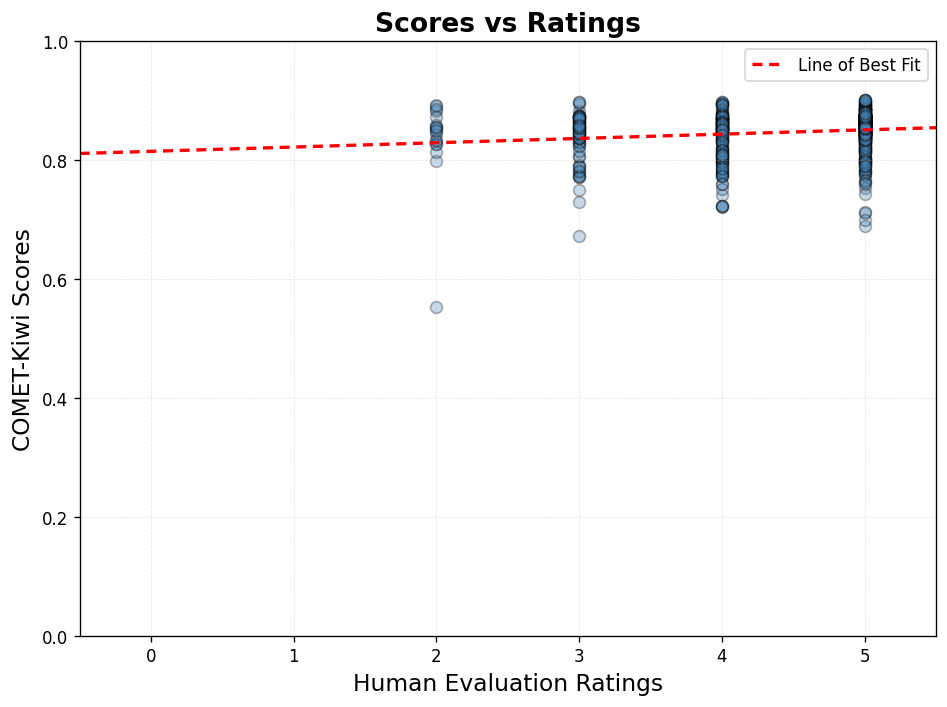

Pearson correlation coefficient: 0.1590
P-value: 3.1278e-05


In [186]:
# build all_ratings and all_scores
all_scores = original_scores.flatten()
all_ratings = original_ratings.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Ratings', fontsize=14)
plt.ylabel('COMET-Kiwi Scores', fontsize=14)
plt.title('Scores vs Ratings', fontsize=16, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_scores_v_ratings.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


In [163]:
comet_kiwi_selector = []
for j in range(len(numpy_array)):
    cur_score = original_ratings[j][highest_scores_i[j]]
    comet_kiwi_selector.append(cur_score)

comet_kiwi_selector = np.array(comet_kiwi_selector)
print(comet_kiwi_selector[:10])
print(np.mean(comet_kiwi_selector))
print(np.mean(highest_ratings))
print(numpy_array[9])

[3 5 3 4 4 4 4 4 3 2]
4.5
4.882352941176471
[11 'eng_to_fre'
 'By the end of the trading day, shares of Ford had dropped 3.9 per cent, GM was down by 7.3 per cent and shares of Stellantis were off by 4.2 per cent.'
 'news-article'
 'À la fin de la journée de négociation, les actions de Ford avaient chuté de 3,9 %, celles de GM de 7,3 % et celles de Stellantis de 4,2 %.'
 2
 'À la fin de la journée de trading, les actions de Ford avaient chuté de 3,9 %, GM avait baissé de 7,3 % et les actions de Stellantis avaient diminué de 4,2 %.'
 2
 'À la fin de la journée de négociation, les actions de Ford avaient chuté de 3,9 %, celles de GM étaient en baisse de 7,3 % et les actions de Stellantis avaient baissé de 4,2 %.'
 2
 'À la fin de la journée, les actions de Ford avaient chuté de 3,9 %, celles de GM de 7,3 % et celles de Stellantis de 4,2 %.'
 2 '2025-03-27 22:05:26']


In [156]:
# Investigate whether same score means same translator
for j in range(len(numpy_array)):
    row = original_scores[j]
    if len(np.unique(row)) < len(row):  # check for duplicates
        print(f"Row {j} contains duplicated scores:", row)
        print(original_scores[j])
        print(numpy_array[j])
        break

Row 1 contains duplicated scores: [0.86326754 0.86574668 0.86574668 0.86326754]
[0.86326754 0.86574668 0.86574668 0.86326754]
[2 'fre_to_eng' 'Sans même devoir lui parler il sait ce qui ne va pas.'
 'song-lyric' "Without even having to talk to him, he knows what's wrong."
 5 'Without even having to talk to him, he knows what is wrong.' 5
 'Without even having to talk to him, he knows what is wrong.' 5
 "Without even having to talk to him, he knows what's wrong." 5
 '2025-03-27 21:42:13']


In [160]:
import numpy as np

for r in range(len(numpy_array)):
    scores = original_scores[r]
    
    # Check for duplicates
    if len(np.unique(scores)) < len(scores):
        print(f"Row {r} contains duplicated scores: {scores}")
        
        # Compare every pair (i, j)
        for i in range(len(scores)):
            for j in range(i + 1, len(scores)):
                if scores[i] == scores[j]:
                    trans_i = numpy_array[r][4 + 2 * i]
                    trans_j = numpy_array[r][4 + 2 * j]
                    
                    print(f"  Duplicate scores at positions {i} and {j}: {scores[i]}")
                    print(f"    Translation {i}: {trans_i}")
                    print(f"    Translation {j}: {trans_j}")
                    
                    if trans_i == trans_j:
                        print("    ✅ Translations match!")
                    else:
                        print("    ❌ Translations do NOT match.")
        #break  # Remove this if you want to check all rows, not just the first match


Row 1 contains duplicated scores: [0.86326754 0.86574668 0.86574668 0.86326754]
  Duplicate scores at positions 0 and 3: 0.8632675409317017
    Translation 0: Without even having to talk to him, he knows what's wrong.
    Translation 3: Without even having to talk to him, he knows what's wrong.
    ✅ Translations match!
  Duplicate scores at positions 1 and 2: 0.8657466769218445
    Translation 1: Without even having to talk to him, he knows what is wrong.
    Translation 2: Without even having to talk to him, he knows what is wrong.
    ✅ Translations match!
Row 4 contains duplicated scores: [0.84729016 0.79801756 0.79801756 0.84729016]
  Duplicate scores at positions 0 and 3: 0.8472901582717896
    Translation 0: Tell us who gives birth to irresponsible people?
    Translation 3: Tell us who gives birth to irresponsible people?
    ✅ Translations match!
  Duplicate scores at positions 1 and 2: 0.7980175614356995
    Translation 1: Tell us who gives birth to the irresponsible?
    Tra

# COMET22 Evaluation

In [229]:
model2 = load_from_checkpoint(model2_path)

KeyboardInterrupt: 

In [ ]:
comet22_scores = []
comet22_system_scores = []
pairs = [
        (0, 1), (0, 2), (0, 3),
        (1, 0), (1, 2), (1, 3),
        (2, 0), (2, 1), (2, 3),
        (3, 0), (3, 1), (3, 2)
    ]

for j in range(len(numpy_array)):
    print(j)
    src = numpy_array[j][2]
    data = []
    for m, r in pairs:
        cur_mt = numpy_array[j][4 + 2*m]
        cur_ref = numpy_array[j][4 + 2*r]
        cur_rating = numpy_array[j][5 + 2*i]
        data.append(
            {
                "src": src,
                "mt": cur_mt,
                "ref": cur_ref
            }
        )
    # Call predict method:
    model_output = model2.predict(data, batch_size=8, gpus=0) # takes around 5s per iteration
    cur_score = model_output.scores
    cur_system_score = model_output.system_score
    comet22_scores.append(cur_score)
    comet22_system_scores.append(cur_system_score)

comet22_scores = np.array(comet22_scores)
comet22_system_scores = np.array(comet22_system_scores)

In [230]:
print(comet22_scores[:2])
print(comet22_system_scores[:2])
print(np.mean(comet22_scores[:2]))

[[0.91430146 0.93022037 0.91349542 0.89841813 0.89526641 0.85905904
  0.93062711 0.9120602  0.91624582 0.91459036 0.88092899 0.9167152 ]
 [0.93809742 0.93809742 0.96081716 0.93718696 0.95927984 0.93718696
  0.93718696 0.95927984 0.93718696 0.96081716 0.93809742 0.93809742]]
[0.90682738 0.94511096]
0.9259691660602888


In [ ]:
np.save('checkpoints/analysis_solution_data/comet22_scores.npy', comet22_scores)
np.save('checkpoints/analysis_solution_data/comet22_system_scores.npy', comet22_system_scores)

In [274]:
chatgpt_choices1 = np.load('checkpoints/analysis_solution_data/chatgpt_selector1.npy')
print(chatgpt_choices1[:10])

[2 0 2 0 1 1 1 1 0 2]


In [290]:
# Load saved arrays
original_ratings   = np.load('checkpoints/analysis_solution_data/original_ratings.npy')
highest_ratings    = np.load('checkpoints/analysis_solution_data/highest_ratings.npy')
highest_ratings_i  = np.load('checkpoints/analysis_solution_data/highest_ratings_i.npy')
original_scores    = np.load('checkpoints/analysis_solution_data/original_scores.npy')
highest_scores     = np.load('checkpoints/analysis_solution_data/highest_scores.npy')
highest_scores_i   = np.load('checkpoints/analysis_solution_data/highest_scores_i.npy')
comet22_scores           = np.load('checkpoints/analysis_solution_data/comet22_scores.npy')
comet22_system_scores    = np.load('checkpoints/analysis_solution_data/comet22_system_scores.npy')
chatgpt_choices1 = np.load('checkpoints/analysis_solution_data/chatgpt_selector1.npy')

In [291]:
comet22_totals = []
for j in range(len(comet22_scores)):
    cur_scores = comet22_scores[j]
    cur_sums = [0, 0, 0, 0]
    for i, (m, r) in enumerate(pairs):
        cur_sums[m] += cur_scores[i]
        cur_sums[r] += cur_scores[i]
    comet22_totals.append(cur_sums)

comet22_totals = np.array(comet22_totals)
print(comet22_totals[:7])
#print(original_scores[:7])
print(original_ratings[:7])

[[5.50165284 5.36003423 5.50113511 5.40103483]
 [5.67220306 5.66912842 5.66912842 5.67220306]
 [5.13152748 5.13320613 5.00770539 4.54379594]
 [5.59824711 5.57681215 5.27094918 5.54408503]
 [5.52397656 5.51396799 5.51396763 5.52397621]
 [5.24112177 4.97526455 5.36396307 5.36396295]
 [5.29692191 5.25508654 5.31357795 5.30678535]]
[[3 4 5 3]
 [5 5 5 5]
 [4 4 4 3]
 [4 4 5 4]
 [4 5 5 4]
 [4 5 4 4]
 [5 3 3 4]]


Create a selector

In [292]:
# Create a selector

perfect_highest = []

ref_selector = []
mt_selector = []
high_selector = [] # not implementable
low_selector = [] # not implementable
hybrid_selector = [] # pick max cometkiwi
hybrid_selector2 = [] # pick min cometkiwi

elimination_selector_a = []
elimination_selector_b = []
elimination_selector_hybrid = []
elimination_selector_high = []

total_selector = []
total_hybrid_selector = []
total_elimination_hybrid_selector = []

the_eliminator = []

elimination_bracket_selector = []

chatgpt_selector1 = []

for j in range(len(numpy_array)):
    cur_scores = comet22_scores[j]
    max_score_i = np.argmax(cur_scores)
    m, r = pairs[max_score_i]
    ref_selector.append(original_ratings[j][r])
    mt_selector.append(original_ratings[j][m])

    perfect_highest.append(original_ratings[j][np.argmax(original_ratings[j])])

    mr_rating = r if original_ratings[j][r] > original_ratings[j][m] else m
    high_selector.append(original_ratings[j][mr_rating])
    mr_rating_min = r if original_ratings[j][r] < original_ratings[j][m] else m
    low_selector.append(original_ratings[j][mr_rating_min])

    mr_score = r if original_scores[j][r] > original_scores[j][m] else m
    hybrid_selector.append(original_ratings[j][mr_score])
    mr_score_min = m if original_scores[j][r] > original_scores[j][m] else r
    hybrid_selector2.append(original_ratings[j][mr_score_min])

    min_score_i = np.argmin(cur_scores)
    elim_m, elim_r = pairs[min_score_i]
    # Create the full set and eliminate elim_m and elim_r
    remaining = [x for x in (0, 1, 2, 3) if x not in (elim_m, elim_r)]
    a, b = remaining
    elimination_selector_a.append(original_ratings[j][a])
    elimination_selector_b.append(original_ratings[j][b])

    ab_score = a if original_scores[j][a] > original_scores[j][b] else b
    elimination_selector_hybrid.append(original_ratings[j][ab_score])

    ab_rating = a if original_ratings[j][a] > original_ratings[j][b] else b
    elimination_selector_high.append(original_ratings[j][ab_rating])

    total_selector.append(original_ratings[j][np.argmax(comet22_totals[j])])
    total_hybrid_selector.append(original_ratings[j][np.argmax((comet22_totals[j] + 5*original_scores[j]))])

    # total elimination hybrid selector
    cur_kiwi_scores = original_scores[j]
    cur_kiwi_scores[np.argmin(comet22_totals[j])] = 0 # zero out worse comet22 performer
    total_elimination_hybrid_selector.append(original_ratings[j][np.argmax(cur_kiwi_scores)])

    # the eliminator
    remaining = [x for x in (0, 1, 2, 3) if x not in (np.argmin(comet22_totals[j]), 5)]
    new_totals = [0, 0, 0, 0]
    cur_scores = comet22_scores[j]
    for i, (m, r) in enumerate(pairs):
        if (m in remaining and r in remaining):
            new_totals[m] += cur_scores[i]
            new_totals[r] += cur_scores[i]
    the_eliminator.append(original_ratings[j][np.argmax(new_totals)])

    # elimination bracket selector
    cur_comet22_scores = comet22_scores[j]
    alive = np.array([1, 1, 1, 1])
    found_index = 5
    while(True):
        cur_min = np.argmin(cur_comet22_scores)
        cur_comet22_scores[cur_min] = 2 # don't repeat
        (m, r) = pairs[cur_min]
        if (np.sum(alive) == 1):
            found_index = np.argmax(alive)
            break
        else:
            alive[m] = 0
        if (np.sum(alive) == 1):
            found_index = np.argmax(alive)
            break
        else:
            alive[r] = 0
    elimination_bracket_selector.append(original_ratings[j][found_index])

    chatgpt_selector1.append(original_ratings[j][chatgpt_choices1[j]])
    
    
import numpy as np

perfect_highest = np.array(perfect_highest)
ref_selector = np.array(ref_selector)
mt_selector = np.array(mt_selector)
high_selector = np.array(high_selector)
low_selector = np.array(low_selector)
hybrid_selector = np.array(hybrid_selector)
hybrid_selector2 = np.array(hybrid_selector2)
elimination_selector_a = np.array(elimination_selector_a)
elimination_selector_b = np.array(elimination_selector_b)
elimination_selector_hybrid = np.array(elimination_selector_hybrid)
elimination_selector_high = np.array(elimination_selector_high)
total_selector = np.array(total_selector)
total_hybrid_selector = np.array(total_hybrid_selector)
total_elimination_hybrid_selector = np.array(total_elimination_hybrid_selector)
the_eliminator = np.array(the_eliminator)
elimination_bracket_selector = np.array(elimination_bracket_selector)
chatgpt_selector1 = np.array(chatgpt_selector1)

print("perfect_highest:", perfect_highest[:10])
print("ref_selector:", ref_selector[:10])
print("mt_selector:", mt_selector[:10])
print("high_selector:", high_selector[:10])
print("low_selector:", low_selector[:10])
print("hybrid_selector:", hybrid_selector[:10])
print("hybrid_selector2:", hybrid_selector2[:10])
print("elimination_selector_a:", elimination_selector_a[:10])
print("elimination_selector_b:", elimination_selector_b[:10])
print("elimination_selector_hybrid:", elimination_selector_hybrid[:10])
print("elimination_selector_high:", elimination_selector_high[:10])
print("total_selector:", total_selector[:10])
print("total_hybrid_selector:", total_hybrid_selector[:10])
print("total_elimination_hybrid_selector:", total_elimination_hybrid_selector[:10])
print("the_eliminator:", the_eliminator[:10])
print("elimination_bracket_selector:", elimination_bracket_selector[:10])
print("chatgpt_selector1:", chatgpt_selector1[:10])

print("mean perfect_highest:", np.mean(perfect_highest))
print("mean ref_selector:", np.mean(ref_selector))
print("mean mt_selector:", np.mean(mt_selector))
print("mean high_selector:", np.mean(high_selector))
print("mean low_selector:", np.mean(low_selector))
print("mean hybrid_selector:", np.mean(hybrid_selector))
print("mean hybrid_selector2:", np.mean(hybrid_selector2))
print("mean elimination_selector_a:", np.mean(elimination_selector_a))
print("mean elimination_selector_b:", np.mean(elimination_selector_b))
print("mean elimination_selector_hybrid:", np.mean(elimination_selector_hybrid))
print("mean elimination_selector_high:", np.mean(elimination_selector_high))
print("mean total_selector:", np.mean(total_selector))
print("mean total_hybrid_selector:", np.mean(total_hybrid_selector))
print("mean total_elimination_hybrid_selector:", np.mean(total_elimination_hybrid_selector))
print("mean the_eliminator:", np.mean(the_eliminator))
print("mean elimination_bracket_selector:", np.mean(elimination_bracket_selector))
print("mean chatgpt_selector1:", np.mean(chatgpt_selector1))


perfect_highest: [5 5 4 5 5 5 5 4 5 2]
ref_selector: [3 5 4 4 4 4 4 4 4 2]
mt_selector: [5 5 4 4 4 4 5 4 5 2]
high_selector: [5 5 4 4 4 4 5 4 5 2]
low_selector: [3 5 4 4 4 4 4 4 4 2]
hybrid_selector: [3 5 4 4 4 4 4 4 5 2]
hybrid_selector2: [5 5 4 4 4 4 5 4 4 2]
elimination_selector_a: [3 5 4 4 4 4 3 3 5 2]
elimination_selector_b: [5 5 4 4 5 4 4 4 4 2]
elimination_selector_hybrid: [3 5 4 4 4 4 4 3 5 2]
elimination_selector_high: [5 5 4 4 5 4 4 4 5 2]
total_selector: [3 5 4 4 4 4 3 4 4 2]
total_hybrid_selector: [3 5 4 4 4 4 4 4 5 2]
total_elimination_hybrid_selector: [3 5 4 4 4 4 4 3 5 2]
the_eliminator: [5 5 4 4 4 4 5 3 4 2]
elimination_bracket_selector: [3 5 4 4 4 4 3 4 4 2]
chatgpt_selector1: [5 5 4 4 5 5 3 4 5 2]
mean perfect_highest: 4.882352941176471
mean ref_selector: 4.635294117647059
mean mt_selector: 4.629411764705883
mean high_selector: 4.741176470588235
mean low_selector: 4.523529411764706
mean hybrid_selector: 4.670588235294118
mean hybrid_selector2: 4.594117647058823
mean e

ChatGPT Selector

In [279]:
print(numpy_array[:2])

[[1 'fre_to_eng'
  "Maman dit que lorsqu'on cherche bien on finit toujours par trouver."
  'song-lyric'
  'Mom says that when you look hard you always end up finding something.'
  3 'Mom says that when you look carefully, you always end up finding.' 4
  'Mom says that when you look hard enough, you always end up finding it.'
  5
  "Mom says that if you look hard enough, you'll always find something."
  3 '2025-03-27 21:41:12']
 [2 'fre_to_eng' 'Sans même devoir lui parler il sait ce qui ne va pas.'
  'song-lyric'
  "Without even having to talk to him, he knows what's wrong." 5
  'Without even having to talk to him, he knows what is wrong.' 5
  'Without even having to talk to him, he knows what is wrong.' 5
  "Without even having to talk to him, he knows what's wrong." 5
  '2025-03-27 21:42:13']]


In [ ]:
from openai import OpenAI

# Set your OpenAI API key
load_dotenv()  # load .env variables into environment

# Use the key from the env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

system_prompt = """
You are an expert in machine translation evaluation. Your task is to choose the best translation from a set of candidate translations, based on accuracy, fluency, and closeness to the reference. You will be given a reference translation and a list of candidates. Respond only with the index (0-based) of the best translation.
"""

chatgpt_selector = []
for j in range(len(numpy_array)):
    cur_row = numpy_array[j]

    user_prompt = f"""
    Language: {cur_row[1]}
    Reference: {cur_row[2]}

    Candidate Translations:
    0: {cur_row[4]}
    1: {cur_row[6]}
    2: {cur_row[8]}
    3: {cur_row[10]}

    Which one is the best translation? Respond only with the index (0–3).
    """

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ]
    )

    # print(completion.choices[0].message)
    result = completion.choices[0].message.content  # Correctly access content
    print(result)
    chatgpt_selector.append(result)

In [271]:
print(chatgpt_selector)

['2', '0', '2', '0', '1', '1', '1', '1', '0', '2', '1', '0', '2', '0', '1', '0', '1', '0', '3', '3', '1', '0', '1', '0', '0', '0', '2', '0', '2', '\n2', '0', '1', '0', '1', '1', '0', '1', '2', '2', '0', '2', '3', '3', '1', '1', '3', '2', '1', '2', '0', '3', '0', '1', '2', '1', '0', '2', '2', '1', '0', '0', '0', '1', '0', '0', '0', '3', '0', '0', '0', '3', '1', '1', '2', '1', '0', '2', '3', '1', '1', '1', '3', '0', '1', '1', '1', '1', '1', '0', '0', '3', '0', '0', '1', '3', '1', '1', '0', '1', '1', '3', '1', '1', '1', '1', '0', '0', '1', '0', '0', '1', '2', '0', '3', '0', '0', '1', '1', '2', '1', '2', '0', '1', '2', '1', '1', '0', '0', '0', '1', '0', '1', '2', '1', '3', '1', '3', '1', '0', '1', '1', '2', '2', '2', '2', '1', '2', '0', '0', '1', '0', '1', '0', '1', '3', '0', '0', '0', '3', '0', '1', '1', '0', '0', '0', '3', '2', '0', '0', '1']


In [ ]:
# Clean and convert to integers
chatgpt_selector_clean = np.array([int(s.strip()) for s in chatgpt_selector])

print(chatgpt_selector_clean)
np.save('checkpoints/analysis_solution_data/chatgpt_selector1.npy', chatgpt_selector_clean)

[2 0 2 0 1 1 1 1 0 2 1 0 2 0 1 0 1 0 3 3 1 0 1 0 0 0 2 0 2 2 0 1 0 1 1 0 1
 2 2 0 2 3 3 1 1 3 2 1 2 0 3 0 1 2 1 0 2 2 1 0 0 0 1 0 0 0 3 0 0 0 3 1 1 2
 1 0 2 3 1 1 1 3 0 1 1 1 1 1 0 0 3 0 0 1 3 1 1 0 1 1 3 1 1 1 1 0 0 1 0 0 1
 2 0 3 0 0 1 1 2 1 2 0 1 2 1 1 0 0 0 1 0 1 2 1 3 1 3 1 0 1 1 2 2 2 2 1 2 0
 0 1 0 1 0 1 3 0 0 0 3 0 1 1 0 0 0 3 2 0 0 1]


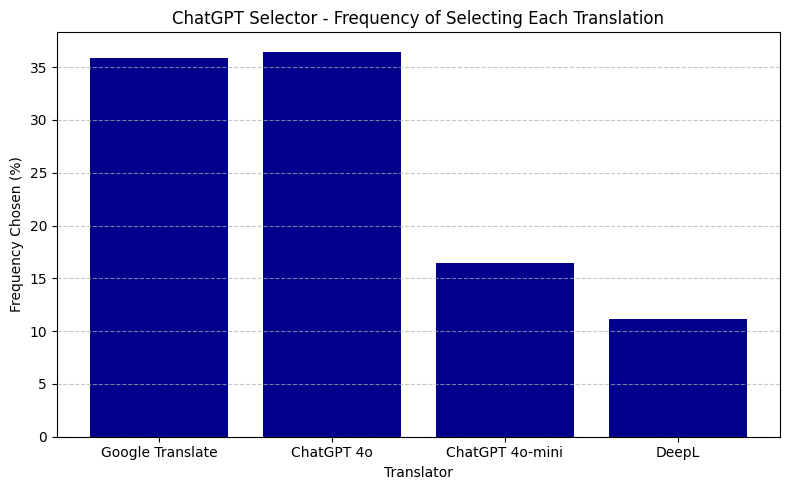

In [303]:
import numpy as np
import matplotlib.pyplot as plt

# Your array
data = np.array([2, 0, 2, 0, 1, 1, 1, 1, 0, 2, 1, 0, 2, 0, 1, 0, 1, 0, 3, 3, 1, 0,
                 1, 0, 0, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 3, 3, 1,
                 1, 3, 2, 1, 2, 0, 3, 0, 1, 2, 1, 0, 2, 2, 1, 0, 0, 0, 1, 0, 0, 0,
                 3, 0, 0, 0, 3, 1, 1, 2, 1, 0, 2, 3, 1, 1, 1, 3, 0, 1, 1, 1, 1, 1,
                 0, 0, 3, 0, 0, 1, 3, 1, 1, 0, 1, 1, 3, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                 1, 2, 0, 3, 0, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 1, 0, 1,
                 2, 1, 3, 1, 3, 1, 0, 1, 1, 2, 2, 2, 2, 1, 2, 0, 0, 1, 0, 1, 0, 1,
                 3, 0, 0, 0, 3, 0, 1, 1, 0, 0, 0, 3, 2, 0, 0, 1])
data = chatgpt_selector_clean

# Your custom labels for values 0, 1, 2, 3 (in order)
custom_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL']

# Count frequencies
unique, counts = np.unique(data, return_counts=True)
frequencies = dict(zip(unique, counts))

# Calculate percentages
total = len(data)
percentages = [frequencies.get(i, 0) / total * 100 for i in range(len(custom_labels))]

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(custom_labels, percentages, color='darkblue')
plt.title('ChatGPT Selector - Frequency of Selecting Each Translation')
plt.xlabel('Translator')
plt.ylabel('Frequency Chosen (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_chatgpt_selection_choices')
plt.show()


Graph this

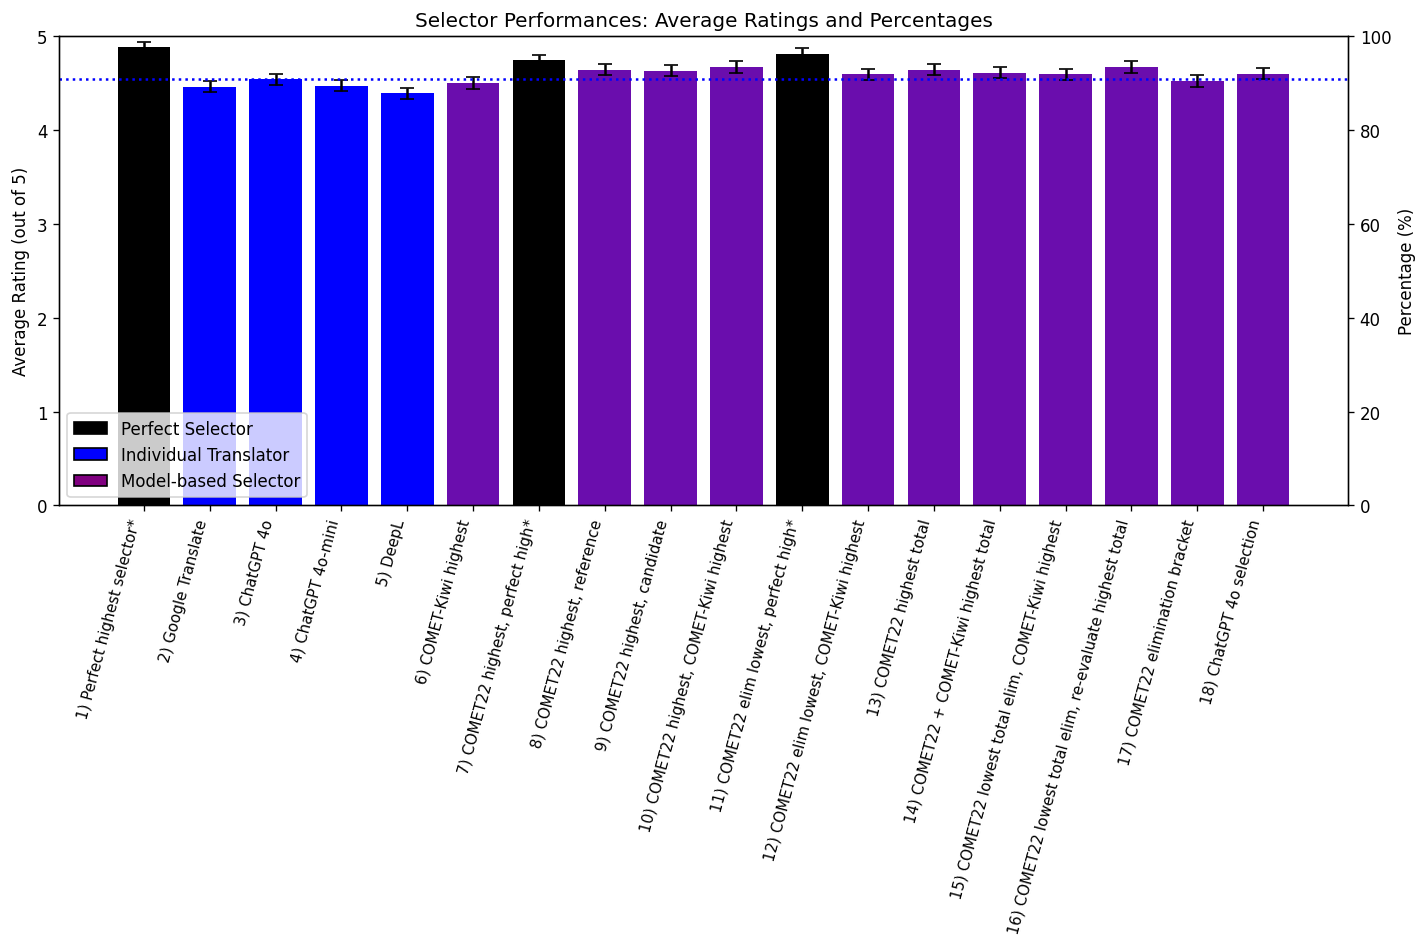

In [320]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Labels and data (same as before)
labels = [
    "Perfect highest selector*", "Google Translate", "ChatGPT 4o", "ChatGPT 4o-mini", "DeepL",
    "COMET-Kiwi highest", "COMET22 highest, perfect high*", "COMET22 highest, reference",
    "COMET22 highest, candidate", "COMET22 highest, COMET-Kiwi highest",
    "COMET22 elim lowest, perfect high*", "COMET22 elim lowest, COMET-Kiwi highest",
    "COMET22 highest total", "COMET22 + COMET-Kiwi highest total",
    "COMET22 lowest total elim, COMET-Kiwi highest",
    "COMET22 lowest total elim, re-evaluate highest total",
    "COMET22 elimination bracket", "ChatGPT 4o selection"
]

ratings = np.array([
    4.88, 4.46, 4.54, 4.47, 4.39,
    4.50, 4.74, 4.64, 4.63, 4.67,
    4.81, 4.59, 4.64, 4.61,
    4.59, 4.67, 4.52, 4.60
])

rating_errors = np.full_like(ratings, 0.06)
percentages = ratings * 20
percentage_errors = np.full_like(percentages, 1.2)

is_perfect = np.array([
    True, False, False, False, False,
    False, True, False, False, False,
    True, False, False, False,
    False, False, False, False
])

# Color logic
colors = []
for i in range(len(ratings)):
    if is_perfect[i]:
        colors.append("black")
    elif 1 <= i <= 4:
        colors.append("blue")
    else:
        colors.append("#6a0dad")

# Add evaluator numbers to labels
labels_numbered = [f"{i+1}) {label}" for i, label in enumerate(labels)]

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 8), dpi=120)
x = np.arange(len(labels))

bars = ax1.bar(x, ratings, yerr=rating_errors, color=colors, capsize=4)
ax1.set_ylabel("Average Rating (out of 5)")
ax1.set_ylim(0, 5)

# Draw horizontal line at ChatGPT 4o score (index 2 → 4.54)
chatgpt_score = ratings[2]
ax1.axhline(chatgpt_score, color='blue', linestyle='dotted', linewidth=1.5)

# Secondary percentage scale
ax2 = ax1.twinx()
ax2.set_ylabel("Percentage (%)")
ax2.set_ylim(0, 100)

# Label ticks
ax1.set_xticks(x)
ax1.set_xticklabels(labels_numbered, rotation=75, ha="right", fontsize=9)
ax1.set_title("Selector Performances: Average Ratings and Percentages")

# Legend
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Perfect Selector'),
    Patch(facecolor='blue', edgecolor='black', label='Individual Translator'),
    Patch(facecolor='purple', edgecolor='black', label='Model-based Selector')
]
ax1.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_selector_performances_bargraph.png')
plt.show()


Evaluate Correlations

In [ ]:
bests = []
worsts = []
avgs = []
refs = []
mts = []
for j in range(len(numpy_array)):
    cur_scores = comet22_scores[j]
    cur_ratings = original_ratings[j]
    cur_bests = []
    cur_worsts = []
    cur_avgs = []
    cur_refs = []
    cur_mts = []
    for i, (m, r) in enumerate(pairs):
        cur_score = cur_scores[i]
        ref = cur_ratings[r]
        mt = cur_ratings[m]
        best = max(mt, ref)
        worst = min(mt, ref)
        avg = (mt + ref) / 2
        cur_bests.append(best)
        cur_worsts.append(worst)
        cur_avgs.append(avg)
        cur_refs.append(ref)
        cur_mts.append(mt)
    bests.append(cur_bests)
    worsts.append(cur_worsts)
    avgs.append(cur_avgs)
    refs.append(cur_refs)
    mts.append(cur_mts)

bests = np.array(bests)
worsts = np.array(worsts)
avgs = np.array(avgs)
refs = np.array(refs)
mts = np.array(mts)

print(bests[:2])
print(worsts[:2])
print(avgs[:2])
print(refs[:2])
print(mts[:2])


[[4 5 3 4 5 4 5 5 5 3 4 5]
 [5 5 5 5 5 5 5 5 5 5 5 5]]
[[3 3 3 3 4 3 3 4 3 3 3 3]
 [5 5 5 5 5 5 5 5 5 5 5 5]]
[[3.5 4.  3.  3.5 4.5 3.5 4.  4.5 4.  3.  3.5 4. ]
 [5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5. ]]
[[4 5 3 3 5 3 3 4 3 3 4 5]
 [5 5 5 5 5 5 5 5 5 5 5 5]]
[[3 3 3 4 4 4 5 5 5 3 3 3]
 [5 5 5 5 5 5 5 5 5 5 5 5]]


In [ ]:
arrays = {
    "bests": bests,
    "worsts": worsts,
    "avgs": avgs,
    "refs": refs,
    "mts": mts
}

for name, arr in arrays.items():
    flat = np.round(arr.flatten()).astype(int)  # Flatten and round (for avg values)
    counts = Counter(flat)
    print(f"{name} counts:")
    for i in range(1, 6):
        print(f"  {i}: {counts[i]}")

bests counts:
  1: 0
  2: 26
  3: 60
  4: 334
  5: 1620
worsts counts:
  1: 0
  2: 88
  3: 372
  4: 644
  5: 936
avgs counts:
  1: 0
  2: 36
  3: 66
  4: 1002
  5: 936
refs counts:
  1: 0
  2: 57
  3: 216
  4: 489
  5: 1278
mts counts:
  1: 0
  2: 57
  3: 216
  4: 489
  5: 1278


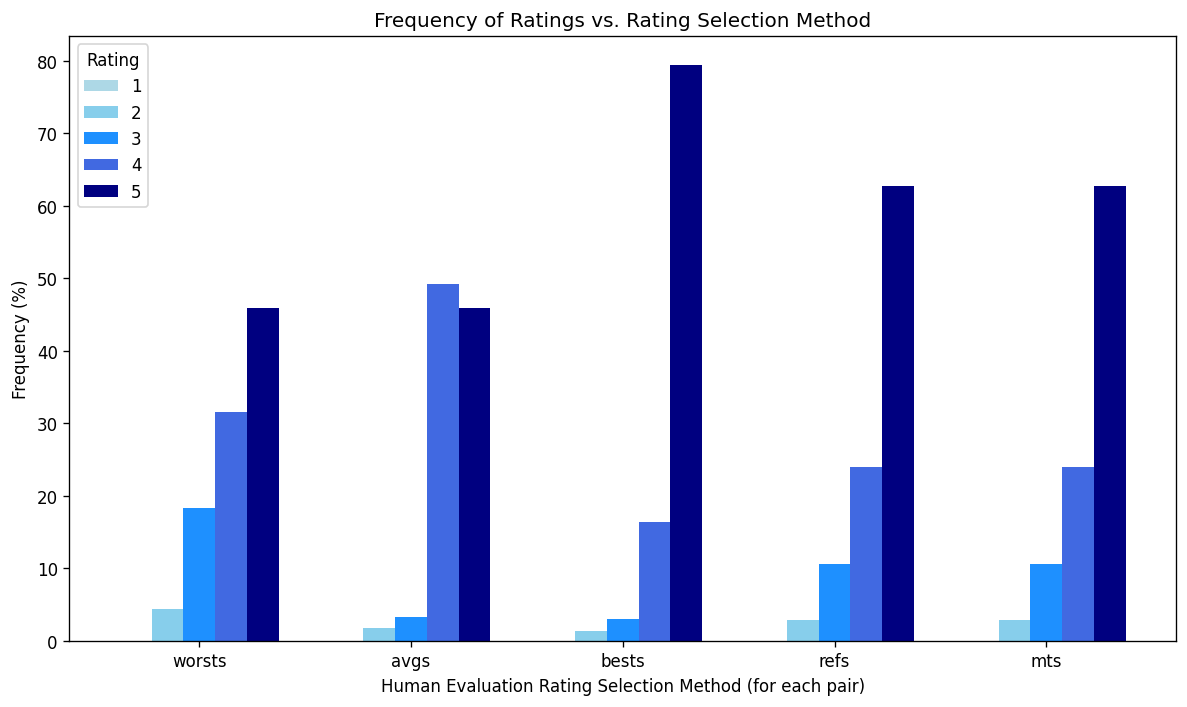

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Assuming you already have these arrays defined: bests, worsts, avgs, refs, mts

arrays = {
    "worsts": worsts,
    "avgs": avgs,
    "bests": bests,
    "refs": refs,
    "mts": mts
}

ratings = [1, 2, 3, 4, 5]
dataset_names = list(arrays.keys())

# Count ratings per dataset
counts_per_dataset = []
for name in dataset_names:
    flat = np.round(arrays[name].flatten()).astype(int)
    counts = Counter(flat)
    #counts_per_dataset.append([counts[r] for r in ratings])
    total = sum(counts.values())
    percentages = [(counts[r] / total * 100) if total > 0 else 0 for r in ratings]
    counts_per_dataset.append(percentages)

# Transpose so each rating becomes a group of bars
counts_per_rating = list(zip(*counts_per_dataset))  # shape: 5 x num_datasets

# Colors: light blue to navy
rating_colors = ['#add8e6', '#87ceeb', '#1e90ff', '#4169e1' , '#000080']  # lightblue → navy

x = np.arange(len(dataset_names))  # Position of each dataset group
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
for i, (rating, color) in enumerate(zip(ratings, rating_colors)):
    ax.bar(x + i * width, counts_per_rating[i], width, label=f'{rating}', color=color)

ax.set_xlabel('Human Evaluation Rating Selection Method (for each pair)')
ax.set_ylabel('Frequency (%)')
ax.set_title('Frequency of Ratings vs. Rating Selection Method')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(dataset_names)
ax.legend(title="Rating")

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_comet22_bargraph_freq_percent')
plt.show()


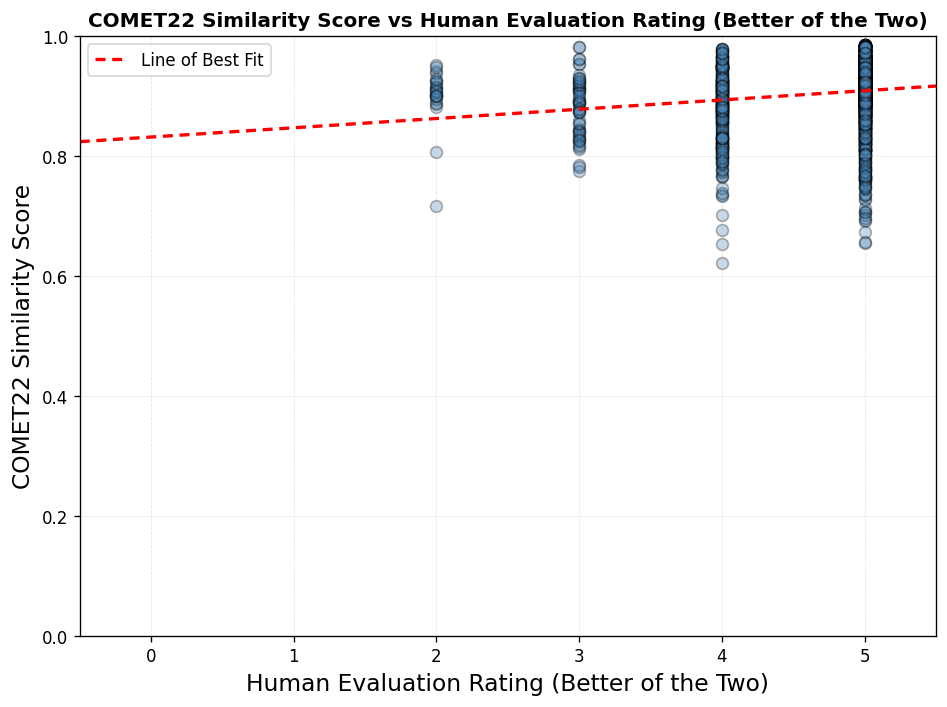

Pearson correlation coefficient: 0.1629
P-value: 1.3513e-13


In [ ]:
# build all_ratings and all_scores
all_scores = comet22_scores.flatten()
all_ratings = bests.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Rating (Better of the Two)', fontsize=14)
plt.ylabel('COMET22 Similarity Score', fontsize=14)
plt.title('COMET22 Similarity Score vs Human Evaluation Rating (Better of the Two)', fontsize=12, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_comet22best.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


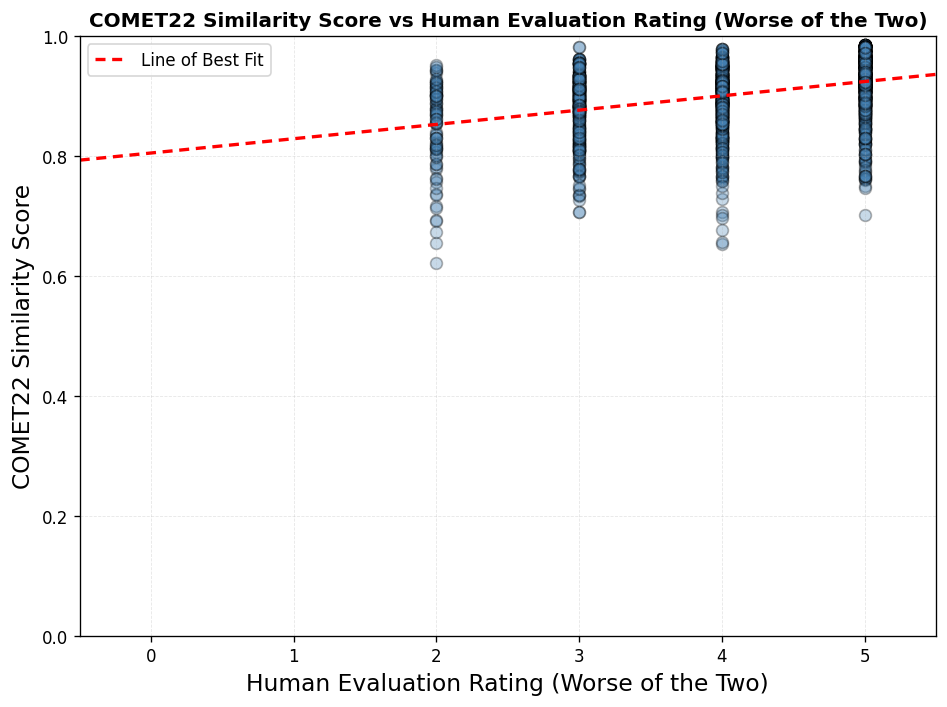

Pearson correlation coefficient: 0.3866
P-value: 1.0697e-73


In [ ]:
# build all_ratings and all_scores
all_scores = comet22_scores.flatten()
all_ratings = worsts.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Rating (Worse of the Two)', fontsize=14)
plt.ylabel('COMET22 Similarity Score', fontsize=14)
plt.title('COMET22 Similarity Score vs Human Evaluation Rating (Worse of the Two)', fontsize=12, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_comet22worst.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


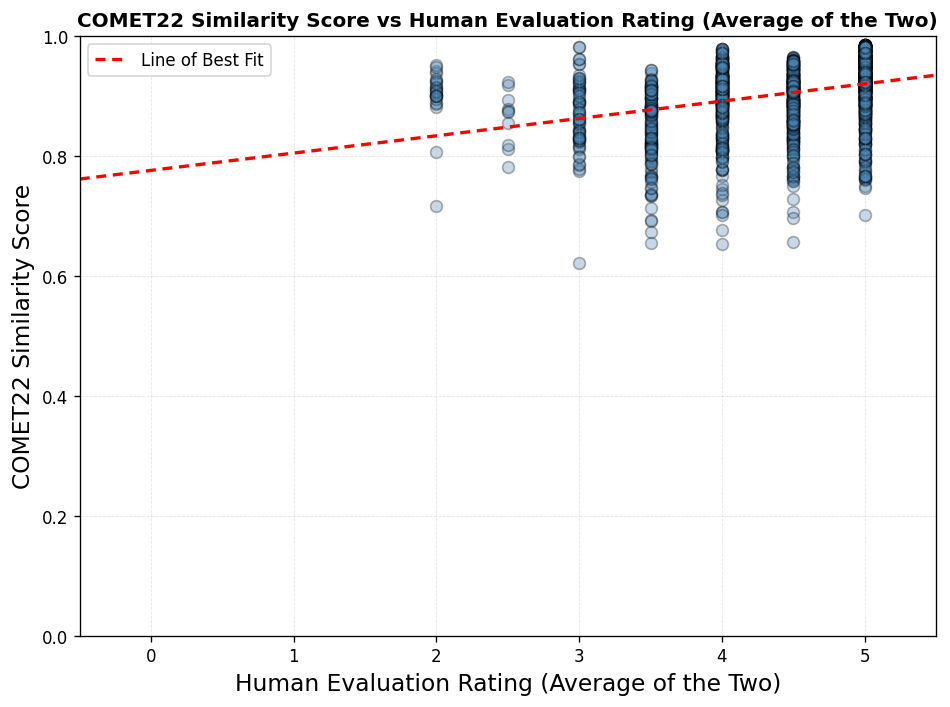

Pearson correlation coefficient: 0.3394
P-value: 3.5347e-56


In [ ]:
# build all_ratings and all_scores
all_scores = comet22_scores.flatten()
all_ratings = avgs.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Rating (Average of the Two)', fontsize=14)
plt.ylabel('COMET22 Similarity Score', fontsize=14)
plt.title('COMET22 Similarity Score vs Human Evaluation Rating (Average of the Two)', fontsize=12, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_comet22average.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


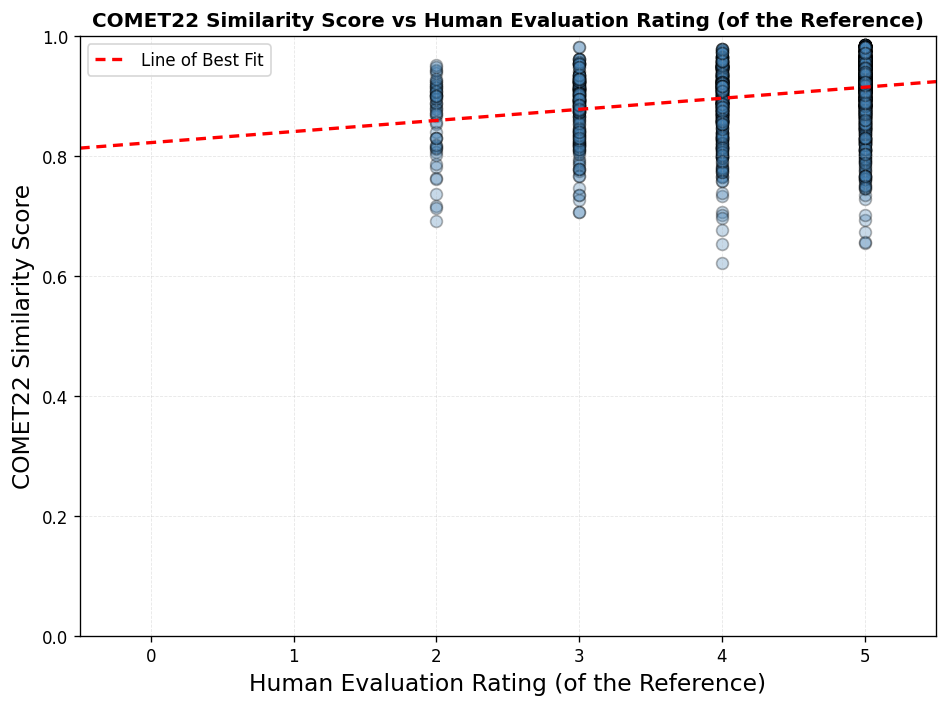

Pearson correlation coefficient: 0.2694
P-value: 2.9614e-35


In [ ]:
# build all_ratings and all_scores
all_scores = comet22_scores.flatten()
all_ratings = refs.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Rating (of the Reference)', fontsize=14)
plt.ylabel('COMET22 Similarity Score', fontsize=14)
plt.title('COMET22 Similarity Score vs Human Evaluation Rating (of the Reference)', fontsize=12, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_comet22refs.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


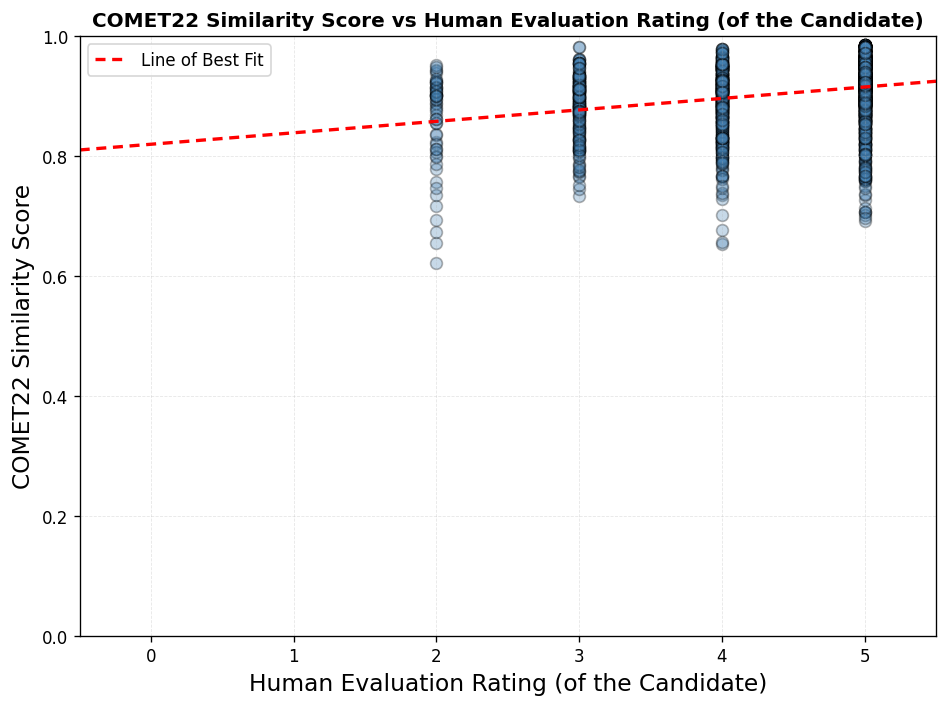

Pearson correlation coefficient: 0.2784
P-value: 1.2586e-37


In [ ]:
# build all_ratings and all_scores
all_scores = comet22_scores.flatten()
all_ratings = mts.flatten()

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Fit a line of best fit (1st degree polynomial)
slope, intercept = np.polyfit(all_ratings, all_scores, 1)
line = np.poly1d((slope, intercept))

# Generate x values for the line
x_vals = np.linspace(-0.5, 5.5, 200)
y_vals = line(x_vals)

# Plot
plt.figure(figsize=(8, 6), dpi=120)

# Scatter
plt.scatter(all_ratings, all_scores, color='steelblue', edgecolor='k', alpha=0.3, s=50)

# Bright red dotted regression line
plt.plot(x_vals, y_vals, color='red', linewidth=2, linestyle=(0, (3, 2)), label='Line of Best Fit')


# Axes
plt.xlim(-0.5, 5.5)
plt.ylim(0, 1)
plt.xlabel('Human Evaluation Rating (of the Candidate)', fontsize=14)
plt.ylabel('COMET22 Similarity Score', fontsize=14)
plt.title('COMET22 Similarity Score vs Human Evaluation Rating (of the Candidate)', fontsize=12, weight='bold')

# Grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# Legend
plt.legend()

# Layout & Save
plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_scatter_comet22mts.png', bbox_inches='tight', dpi=300)
plt.show()

# Pearson correlation
corr_coef, p_value = pearsonr(all_ratings, all_scores)
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")


In [ ]:
for j in len(numpy_array):
    cur_scores = comet22_scores[j]
    max_index = np.argmax(cur_scores)
    max_value = np.max(cur_scores)

TypeError: 'int' object is not iterable

In [ ]:
print(numpy_array[0])

In [ ]:
# dry run
values = np.array([
    [0.91430146, 0.93022037, 0.91349542, 0.89841813, 0.89526641, 0.85905904,
     0.93062711, 0.9120602,  0.91624582, 0.91459036, 0.88092899, 0.9167152]
])
max_value = np.max(values)
max_index = np.argmax(values)

In [ ]:
# Do some investigating into the one specific example
indices = np.argwhere(numpy_array == 124)
print("Indices of 124:", indices[0][0]) # 116
print(numpy_array[116])

Indices of 124: 116
[124 'fre_to_eng'
 "Je savais reconnaître, du premier coup d'œil, la Chine de l'Arizona."
 'book' 'I knew, at first glance, how China was Arizona.' 2
 'I could immediately distinguish China from Arizona at first glance.' 4
 'I could recognize, at first glance, the China of Arizona.' 2
 'I could tell China from Arizona at a glance.' 5 '2025-03-31 14:41:17']


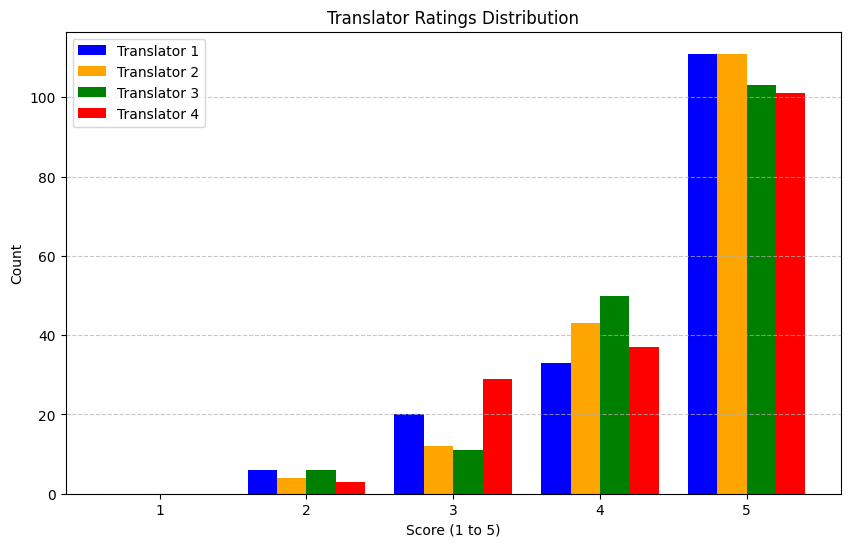

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 4
ratings = [[] for _ in range(num_translators)]

for row in data:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.2

# Translator labels
translator_labels = [f'Translator {i+1}' for i in range(num_translators)]
colors = ['blue', 'orange', 'green', 'red']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    counts = [rating_counts[i][score] for score in score_range]  # Get counts for 1-5
    plt.bar(x + i * bar_width, counts, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Score (1 to 5)')
plt.ylabel('Count')
plt.title('Translator Ratings Distribution')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]


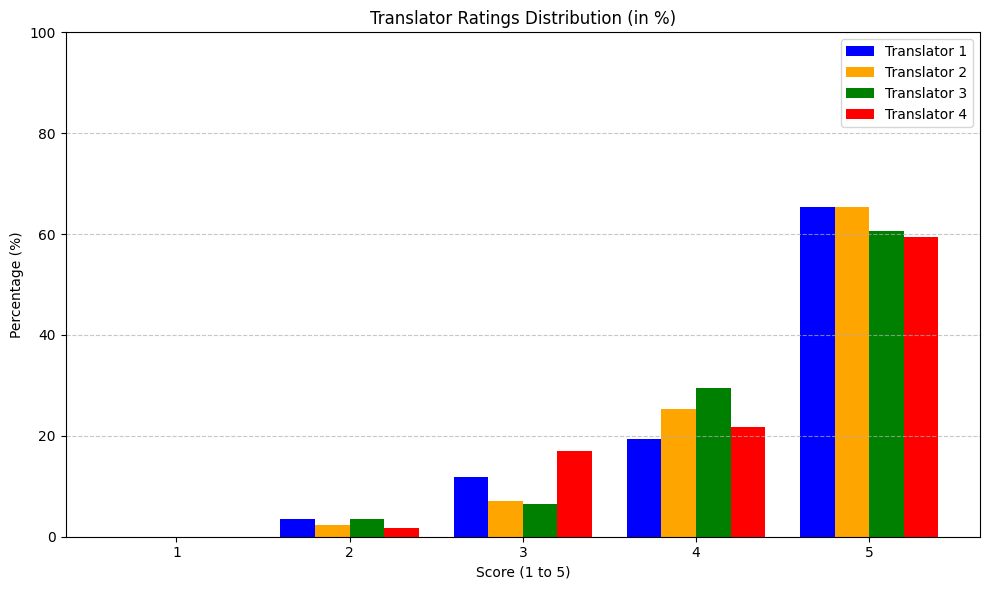

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array  # Ensure the correct variable is used

# Extract translator responses and their ratings
num_translators = 4
ratings = [[] for _ in range(num_translators)]

for row in numpy_array:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Compute total ratings per translator for percentage calculation
total_ratings = [sum(counts.values()) for counts in rating_counts]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.2

# Translator labels
translator_labels = [f'Translator {i+1}' for i in range(num_translators)]
colors = ['blue', 'orange', 'green', 'red']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Score (1 to 5)')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)
plt.title('Translator Ratings Distribution (in %)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


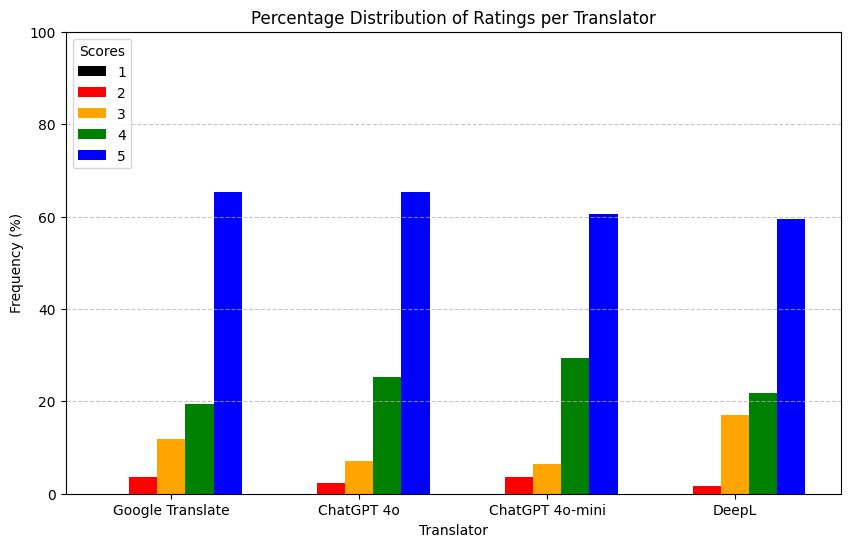

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 5
ratings = [[] for _ in range(num_translators)]

for row in data:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings
    ratings[4].

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Normalize to percentage
percentage_counts = []
for count in rating_counts:
    total = sum(count.values())
    percentage_counts.append({score: (count[score] / total) * 100 if total > 0 else 0 for score in score_range})

# Create bar positions
x = np.arange(num_translators)
bar_width = 0.15

# Score labels
score_labels = [str(score) for score in score_range]
colors = ['black', 'red', 'orange', 'green', 'blue']  # Custom color order

# Plot bars
plt.figure(figsize=(10, 6))

for i, score in enumerate(score_range):
    percentages = [percentage_counts[t][score] for t in range(num_translators)]  # Get percentages per translator
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=f'{score}', color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * 2, ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL'])  # Center tick labels
plt.xlabel('Translator')
plt.ylabel('Frequency (%)')
plt.ylim(0, 100)
plt.title('Percentage Distribution of Ratings per Translator')
plt.legend(title="Scores", loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array

# Extract translator responses and their ratings
num_translators = 5
ratings_average = [0, 0, 0, 0, 0]
ratings_3plus = [0, 0, 0, 0, 0]
ratings_4plus = [0, 0, 0, 0, 0]
ratings_5plus = [0, 0, 0, 0, 0]

for row in numpy_array:
    max_rating = 0
    for i in range(num_translators - 1):
        cur_rating = row[5 + 2 * i]
        ratings_average[i] += cur_rating  # Extract ratings
        if (cur_rating) > max_rating:
            max_rating = cur_rating
        if (cur_rating) >= 5:
            ratings_5plus[i] += 1
        if (cur_rating) >= 4:
            ratings_4plus[i] += 1
        if (cur_rating) >= 3:
            ratings_3plus[i] += 1
    ratings_average[4] += max_rating
    if (max_rating) >= 5:
        ratings_5plus[4] += 1
    if (max_rating) >= 4:
        ratings_4plus[4] += 1
    if (max_rating) >= 3:
        ratings_3plus[4] += 1

# Divide each total by the number of rows to get averages
num_rows = len(numpy_array)
ratings_average = [(x / 5 / num_rows)*100 for x in ratings_average]
ratings_3plus = [(x / num_rows)*100 for x in ratings_3plus]
ratings_4plus = [(x / num_rows)*100 for x in ratings_4plus]
ratings_5plus = [(x / num_rows)*100 for x in ratings_5plus]

print(ratings_average)
print(ratings_3plus)
print(ratings_4plus)
print(ratings_5plus)


[89.29411764705884, 90.70588235294117, 89.41176470588236, 87.76470588235293, 97.6470588235294]
[96.47058823529412, 97.6470588235294, 96.47058823529412, 98.23529411764706, 98.82352941176471]
[84.70588235294117, 90.58823529411765, 90.0, 81.17647058823529, 98.23529411764706]
[65.29411764705883, 65.29411764705883, 60.588235294117645, 59.411764705882355, 91.17647058823529]


In [ ]:
# Statistical analysis

In [ ]:
from scipy.stats import f_oneway

# Each of these should be a list/array of 171 ratings
ratings_translator_1 = numpy_array[:,5]
ratings_translator_2 = numpy_array[:,7]
ratings_translator_3 = numpy_array[:,9]
ratings_translator_4 = numpy_array[:,11]

print(ratings_translator_1[:10])

# Perform one-way ANOVA
f_stat, p_value = f_oneway(ratings_translator_1,
                           ratings_translator_2,
                           ratings_translator_3,
                           ratings_translator_4)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")


[3 5 4 4 4 4 5 3 5 2]
F-statistic: 0.9786
P-value: 4.0229e-01


In [ ]:
import numpy as np

std_devs = [np.std(r, ddof=1) for r in [ratings_translator_1, ratings_translator_2, ratings_translator_3, ratings_translator_4]]
standard_errors = [s / np.sqrt(171) for s in std_devs]

print(std_devs)
print(standard_errors)

[0.8366184233900933, 0.7309240131388098, 0.7705870396389957, 0.8298302050185654]
[0.06397780985722354, 0.05589515629261873, 0.058928263736641284, 0.06345870182409763]


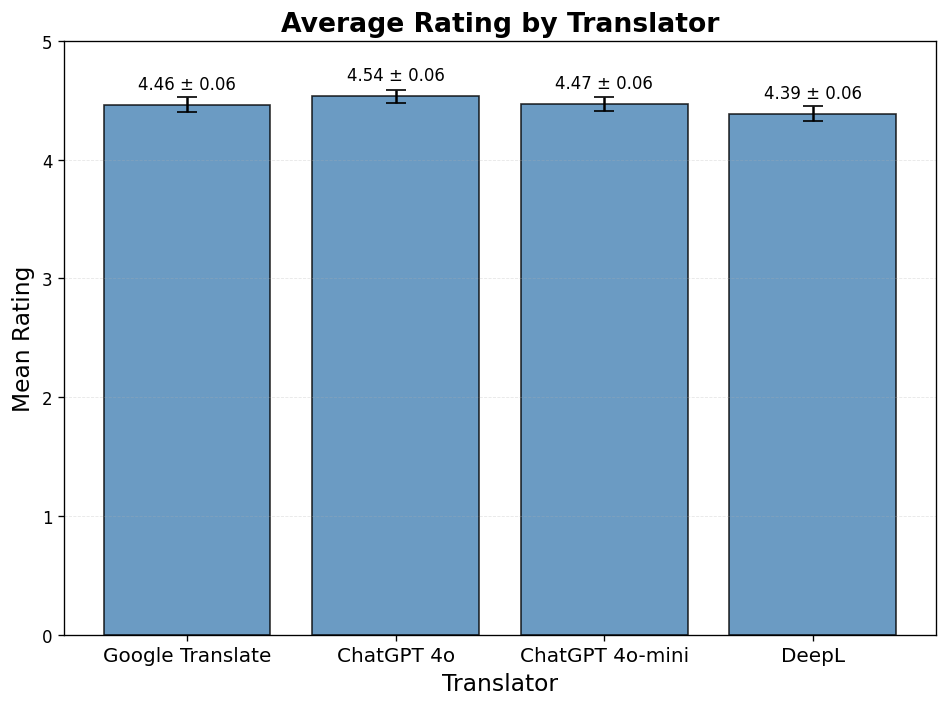

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ratings_array = original_ratings
# Means and standard errors
means = np.mean(ratings_array, axis=0)
stds = np.std(ratings_array, axis=0, ddof=1)
sems = stds / np.sqrt(ratings_array.shape[0])  # Standard error of the mean

# Labels
translator_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL']
x = np.arange(len(translator_labels))

# Plot
plt.figure(figsize=(8, 6), dpi=120)
bars = plt.bar(x, means, yerr=sems, capsize=6, color='steelblue', alpha=0.8, edgecolor='black')

# Add mean ± error on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    label = f"{means[i]:.2f} ± {sems[i]:.2f}"
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.10, label, 
             ha='center', va='bottom', fontsize=10)

# Styling
plt.xticks(x, translator_labels, fontsize=12)
plt.ylabel('Mean Rating', fontsize=14)
plt.xlabel('Translator', fontsize=14)
plt.title('Average Rating by Translator', fontsize=16, weight='bold')
plt.ylim(0, 5)  # ratings are between 1 and 5
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_rating_average-bargraph.png')
plt.show()


In [ ]:
len(numpy_array)

170

[65.29411764705883, 84.70588235294117, 89.29411764705884]
[65.29411764705883, 90.58823529411765, 90.70588235294117]
[60.588235294117645, 90.0, 89.41176470588236]
[59.411764705882355, 81.17647058823529, 87.76470588235293]
[91.17647058823529, 98.23529411764706, 97.6470588235294]


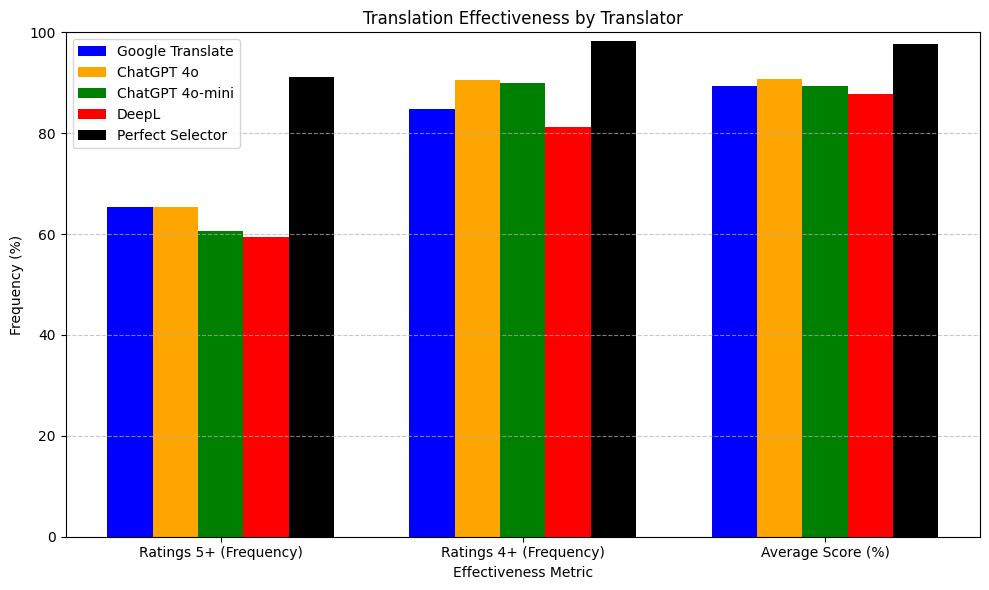

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Extract translator responses and their ratings
num_translators = 5

# Create bar positions
bar_width = 0.15
x = np.arange(3)

# Translator labels
translator_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL', 'Perfect Selector']
colors = ['blue', 'orange', 'green', 'red', 'black']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    cur_bar = [ratings_5plus[i], ratings_4plus[i], ratings_average[i]]
    print(cur_bar)
    plt.bar(x + i * bar_width, cur_bar, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), ['Ratings 5+ (Frequency)', 'Ratings 4+ (Frequency)', 'Average Score (%)'])  # Center tick labels
plt.xlabel('Effectiveness Metric')
plt.ylabel('Frequency (%)')
plt.ylim(0, 100)
plt.title('Translation Effectiveness by Translator')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_effectiveness-bargraph')
plt.show()


In [ ]:
numpy_array2 = numpy_array
for row in numpy_array:
    for i in range(num_translators):
        ratings[i].append(row[5 + 2 * i])  # Extract ratings

[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]
[0.0, 1.1764705882352942, 0.5882352941176471, 7.0588235294117645, 91.17647058823529]


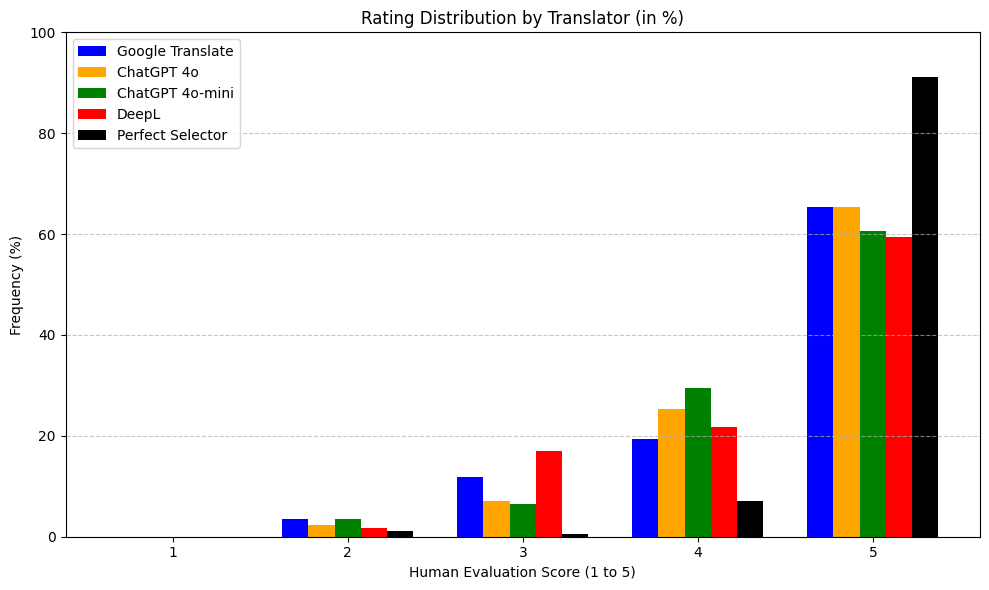

[0.0, 3.5294117647058822, 11.76470588235294, 19.411764705882355, 65.29411764705883]
[0.0, 2.3529411764705883, 7.0588235294117645, 25.294117647058822, 65.29411764705883]
[0.0, 3.5294117647058822, 6.470588235294119, 29.411764705882355, 60.588235294117645]
[0.0, 1.7647058823529411, 17.058823529411764, 21.764705882352942, 59.411764705882355]


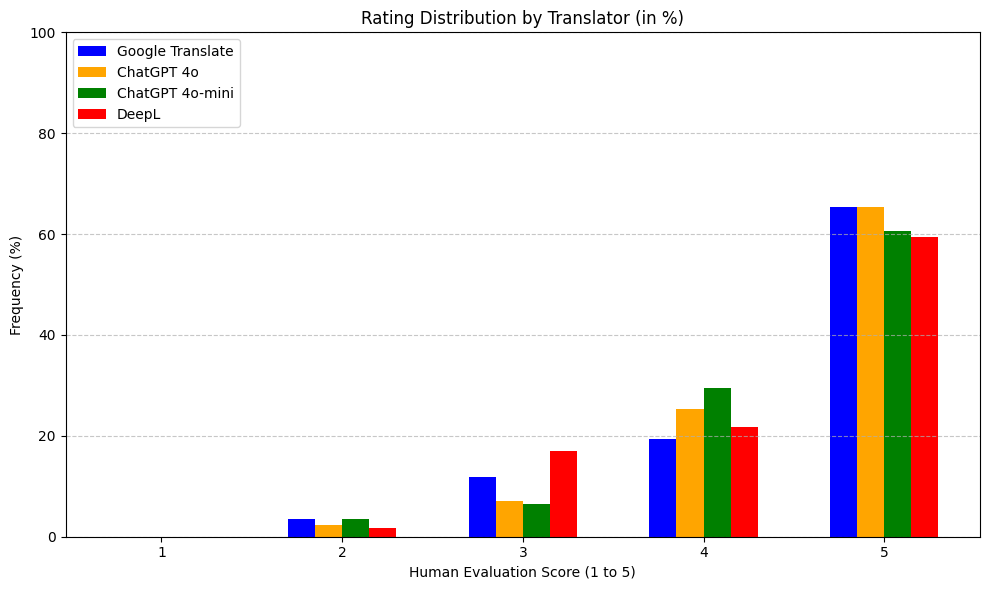

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Sample data (replace with your actual numpy array)
data = numpy_array2  # Ensure the correct variable is used

# Extract translator responses and their ratings
num_translators = 5 # added 1 for the max
ratings = [[] for _ in range(num_translators)]

for row in numpy_array:
    max_rating = 0
    for i in range(num_translators - 1):
        cur_rating = row[5 + 2 * i]
        ratings[i].append(cur_rating)  # Extract ratings
        if (cur_rating) > max_rating:
            max_rating = cur_rating
    ratings[4].append(max_rating)

# Count occurrences of each rating (1-5) for each translator
score_range = range(1, 6)
rating_counts = [Counter(rating) for rating in ratings]

# Compute total ratings per translator for percentage calculation
total_ratings = [sum(counts.values()) for counts in rating_counts]

# Create bar positions
x = np.arange(len(score_range))
bar_width = 0.15

# Translator labels
translator_labels = ['Google Translate', 'ChatGPT 4o', 'ChatGPT 4o-mini', 'DeepL', 'Perfect Selector']
colors = ['blue', 'orange', 'green', 'red', 'black']

# Plot bars
plt.figure(figsize=(10, 6))

for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Human Evaluation Score (1 to 5)')
plt.ylabel('Frequency (%)')
plt.ylim(0,100)
plt.title('Rating Distribution by Translator (in %)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_rating-distribution-bargraph-ideal.png')
plt.show()

# still plot the original
plt.figure(figsize=(10, 6))
num_translators = 4
for i in range(num_translators):
    percentages = [
        (rating_counts[i][score] / total_ratings[i] * 100) if total_ratings[i] > 0 else 0
        for score in score_range
    ]
    print(percentages)
    plt.bar(x + i * bar_width, percentages, width=bar_width, label=translator_labels[i], color=colors[i])

# Labels and legend
plt.xticks(x + bar_width * (num_translators / 2 - 0.5), score_range)  # Center tick labels
plt.xlabel('Human Evaluation Score (1 to 5)')
plt.ylabel('Frequency (%)')
plt.ylim(0,100)
plt.title('Rating Distribution by Translator (in %)')
plt.legend(loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/analysis_app_solution/final_rating-distribution-bargraph-original.png')
plt.show()
